In [ ]:
import sys
import scipy as sc
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.optimize import curve_fit

sys.path.append("scripts/utils/")
import config_functions   as config
import vm_output_handling as vm_output

from plot_utils import hist_to_curve
from experimental_data_class import SegmentationData

In [2]:
def extract_param_from_datasets(cellprops, density_masks, param, frame2h = 1/12):
    """ Function for extracting parameter from several datasets """
    dist = []
    stds = []

    # combine data from all experiments
    for cellprop, mask in zip(cellprops, density_masks):

        if param == "height":
            var = cellprop.h[mask]
            dist.append(var.ravel())
            stds.append(np.ma.std(var, axis=0))

        elif param == "area":
            var = cellprop.A[mask]
            dist.append(var.ravel())
            stds.append(np.ma.std(var, axis=0))

        elif param == "planar":
            var = cellprop.amajor[mask] / cellprop.aminor[mask]
            dist.append(var.ravel())
            stds.append(np.ma.std(var, axis=0))

        elif param == "vertical":
            var = cellprop.h[mask] / np.sqrt(cellprop.A[mask])
            dist.append(var.ravel())
            stds.append(np.ma.std(var, axis=0))

        elif param == "speed":
            var = np.ma.sqrt(cellprop.dx[mask[:-1]]**2 + cellprop.dy[mask[:-1]]**2) / frame2h
            dist.append(var.ravel())
            stds.append(np.ma.std(var, axis=0))

        else:
            print("Error: Do not regonize parameter. Must be either 'height' or 'area'")
            break

    dist = np.ma.concatenate(dist)
    stds = np.ma.concatenate(stds)

    return dist, stds


def extract_param_from_simulation(list_vms, param):
    """ Function for extracting parameter from several simulations """
    dist = []
    stds = []

    # combine data from all experiments
    for list_vm in list_vms:

        if param == "height":
            var = vm_output.get_cell_heights(list_vm)
            dist.append(var.ravel())
            stds.append(np.ma.std(var, axis=0))

        elif param == "area":
            var = vm_output.get_cell_volumes(list_vm) / vm_output.get_cell_heights(list_vm)
            dist.append(var.ravel())
            stds.append(np.ma.std(var, axis=0))

        elif param == "planar":
            var = vm_output.get_cell_aspect_ratios(list_vm)
            dist.append(var.ravel())
            stds.append(np.ma.std(var, axis=0))

        elif param == "vertical":
            var = np.sqrt( vm_output.get_cell_heights(list_vm)**3 / vm_output.get_cell_volumes(list_vm))
            dist.append(var.ravel())
            stds.append(np.ma.std(var, axis=0))

        elif param == "speed":
            vm_output.get_cell_velocities(list_vm)
            var = np.ma.sqrt(vm_output.get_cell_velocities(list_vm)[:,:,0]**2 + vm_output.get_cell_velocities(list_vm)[:,:,1]**2)
            dist.append(var.ravel())
            stds.append(np.ma.std(var, axis=0))

        else:
            print("Error: Do not regonize parameter. Must be either 'height' or 'area'")
            break

    return dist, stds    



""" Functions for fitting to experimental distributions """
def lognorm_distribution(x, a, scale):
    lognorm = sc.stats.lognorm.pdf(x, a, scale=scale)
    return lognorm / np.sum(lognorm)

def gamma_distribution(x, a, scale):
    gamma = sc.stats.gamma.pdf(x, a, scale=scale)
    return gamma / np.sum(gamma)

# Load data

In [3]:
# LOAD EXPERIMENTAL DATA
datasets = ["holomonitor_20240319_A1-13",
            "holomonitor_20240301_B1-4"]
            #"holomonitor_20240319_B1-11",
            #"holomonitor_20240319_A1-9"]


binsize = 200
density = 1900

masks = []
cellprops = []

# Add experimental data
for dataset in datasets:

    cellprop = SegmentationData()
    cellprop.load(f"../../../../hdd_data/silja/VertexModel_data/experimental/processed/{dataset}/cell_props.p")
    cellprop.add_density()

    mask = (cellprop.density > density - binsize / 2) * (cellprop.density < density + binsize / 2)

    masks.append(mask)
    cellprops.append(cellprop)

State loaded from ../../../../hdd_data/silja/VertexModel_data/experimental/processed/holomonitor_20240319_A1-13/cell_props.p.
State loaded from ../../../../hdd_data/silja/VertexModel_data/experimental/processed/holomonitor_20240301_B1-4/cell_props.p.


In [4]:
# LOAD SIMULATION DATA
date  = [20260428, 20260504, 20260504]
gamma = [27, 13]
lmbd  = [100, 50, 200]
v0    = [120, 100]
tau   = [120, 100]
eta   = [200, 100]


paths = [f"../../../../hdd_data/silja/VertexModel_data/simulated/raw/nodivision_{date[i]}_N42_L600_gamma{gamma[0]}_lambda{lmbd[i]}_v0{v0[0]}_taup{tau[0]}_eta{eta[0]}.p" for i in range(3)]

list_vms = []
for filepath in paths:
    config_path = f"configs/{Path(filepath).stem}.json"
    config_file = config.load(config_path)

    # Compute time period between frames
    dt = config_file["simulation"]["dt"]
    T  = config_file["simulation"]["period"]
    df = T * dt

    # Load frames as vm objects
    list_vm, init_vm = vm_output.load(filepath, df=df)
    list_vms.append(list_vm)


colors = mpl.colormaps["Reds"](np.linspace(0.4, 0.9, len(list_vms)))

In [5]:
len(list_vms[0])

99

## Height distribution

In [14]:
# Extract experimental distributions
tmp_dist, tmp_std = extract_param_from_datasets(cellprops, masks, param="height")

# get histogram curves
hmin = 1
hmax = 12
h,   freq_h, _   = hist_to_curve(tmp_dist, 36,  hist_range=[hmin, hmax])
std, freq_std, _ = hist_to_curve(tmp_std,  36, hist_range=[1e-4, hmax/6])

# Normalise
freq_h   = freq_h   / np.ma.sum(freq_h)
freq_std = freq_std / np.ma.sum(freq_std[1:])

# Express std as relative of mean
std = std / np.ma.mean(tmp_dist)

In [15]:
# Fit lognormal to distributions to experimental data
h_params, h_popt = curve_fit(lognorm_distribution, h, freq_h, p0=[1, np.mean(tmp_dist)])
h_lognorm        = lognorm_distribution(h, *h_params)

print("Height distribution")
print(f"Shape parameter: {h_params[0]:0.2f} +/- {h_popt[0,0]:0.2f}")
print(f"Scale parameter: {h_params[1]:0.2f} +/- {h_popt[1,1]:0.2f}")


std_params, std_popt = curve_fit(lognorm_distribution, std, freq_std, p0=[1, np.mean(tmp_std) / np.mean(tmp_dist)])
std_lognorm          = lognorm_distribution(std, *std_params)

print("\nHeight fluctuation")
print(f"Shape parameter: {std_params[0]:0.2f} +/- {std_popt[0,0]:0.2f}")
print(f"Scale parameter: {std_params[1]:0.2f} +/- {std_popt[1,1]:0.2f}")

Height distribution
Shape parameter: 0.22 +/- 0.00
Scale parameter: 4.49 +/- 0.00

Height fluctuation
Shape parameter: 0.70 +/- 0.00
Scale parameter: 0.07 +/- 0.00


In [16]:
# Extract simulation distributions
tmp_dists, tmp_stds = extract_param_from_simulation(list_vms, param="height")

# get histogram curves
h_sim        = []
std_sim      = []
freq_h_sim   = []
freq_std_sim = []
for tmp_dist, tmp_std in zip(tmp_dists, tmp_stds):
    h_tmp,   freq_h_tmp, _   = hist_to_curve(tmp_dist, 36,  hist_range=[hmin, hmax])
    std_tmp, freq_std_tmp, _ = hist_to_curve(tmp_std,  36, hist_range=[1e-4, hmax/6])

    # Normalise
    freq_h_tmp   = freq_h_tmp   / np.ma.sum(freq_h_tmp)
    freq_std_tmp = freq_std_tmp / np.ma.sum(freq_std_tmp[1:])

    # Express std as relative of mean
    std_tmp = std_tmp / np.ma.mean(tmp_dist)

    h_sim.append(h_tmp)
    std_sim.append(std_tmp)
    freq_h_sim.append(freq_h_tmp)
    freq_std_sim.append(freq_std_tmp)

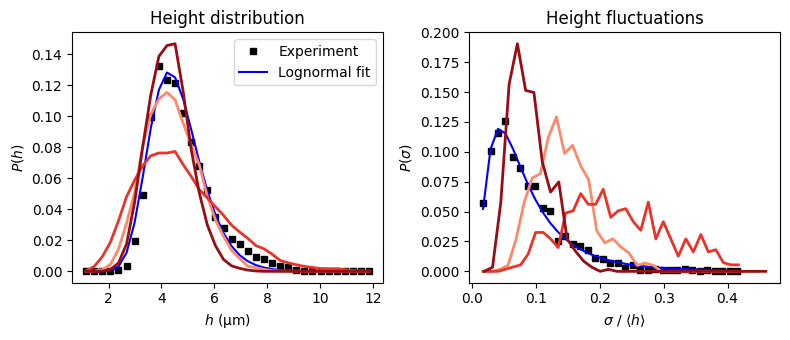

In [20]:
# create figure
plt.figure(figsize=(8,3.5))
plt.subplot(121)
plt.title("Height distribution")
plt.xlabel(r"$h$ (µm)")
plt.ylabel(r"$P(h)$")

plt.plot(h,     freq_h,     'ks', ms=4, label="Experiment")
plt.plot(h,     h_lognorm,  'b-',       label="Lognormal fit")
for h_tmp, freq_tmp, c in zip(h_sim, freq_h_sim, colors):
    plt.plot(h_tmp, freq_tmp, '-', c=c, lw=2)
plt.legend()

# create subfigure
plt.subplot(122)
plt.title("Height fluctuations")
plt.xlabel(r"$\sigma~/~\langle h \rangle$")
plt.ylabel(r"$P(\sigma)$")

plt.plot(std[1:],     freq_std[1:],     'ks', ms=4)
plt.plot(std[1:],     std_lognorm[1:],  'b-')
for std_tmp, freq_tmp, c in zip(std_sim, freq_std_sim, colors):
    plt.plot(std_tmp[1:], freq_tmp[1:], '-', c=c, lw=2)

# save
plt.tight_layout()
# plt.savefig("results/tmp/height_distribution_and_fluctuation.png", dpi=300)

## Area distribution

In [21]:
# Extract experimental distributions
tmp_dist, tmp_std = extract_param_from_datasets(cellprops, masks, param="area")

# get histogram curves
Amin = 100
Amax = 2000
A,   freq_A, _   = hist_to_curve(tmp_dist, 36, hist_range=[Amin, Amax])
std, freq_std, _ = hist_to_curve(tmp_std,  36, hist_range=[1e-4, Amax/6])

# Normalise
freq_A   = freq_A   / np.ma.sum(freq_A)
freq_std = freq_std / np.ma.sum(freq_std[1:])

# Express std as relative of mean
std = std / np.ma.mean(tmp_dist)

In [22]:
# Fit lognormal to distributions to experimental data
A_params, A_popt = curve_fit(lognorm_distribution, A, freq_A, p0=[1, np.mean(tmp_dist)])
A_lognorm      = lognorm_distribution(A, *A_params)

print("Area distribution")
print(f"Shape parameter: {A_params[0]:0.2f} +/- {A_popt[0,0]:0.2f}")
print(f"Scale parameter: {A_params[1]:0.2f} +/- {A_popt[1,1]:0.2f}")


std_params, std_popt = curve_fit(lognorm_distribution, std, freq_std, p0=[1, np.mean(tmp_std) / np.mean(tmp_dist)])
std_lognorm          = lognorm_distribution(std, *std_params)

print("\nArea fluctuation")
print(f"Shape parameter: {std_params[0]:0.2f} +/- {std_popt[0,0]:0.2f}")
print(f"Scale parameter: {std_params[1]:0.2f} +/- {std_popt[1,1]:0.2f}")

Area distribution
Shape parameter: 0.39 +/- 0.00
Scale parameter: 501.45 +/- 6.18

Area fluctuation
Shape parameter: 0.67 +/- 0.00
Scale parameter: 0.09 +/- 0.00


In [23]:
# Extract simulation distributions
tmp_dists, tmp_stds = extract_param_from_simulation(list_vms, param="area")

# get histogram curves
A_sim        = []
std_sim      = []
freq_A_sim   = []
freq_std_sim = []
for tmp_dist, tmp_std in zip(tmp_dists, tmp_stds):
    A_tmp,   freq_A_tmp, _   = hist_to_curve(tmp_dist, 36, hist_range=[Amin, Amax])
    std_tmp, freq_std_tmp, _ = hist_to_curve(tmp_std,  36, hist_range=[1e-4, Amax/6])

    # Normalise
    freq_A_tmp   = freq_A_tmp   / np.ma.sum(freq_A_tmp)
    freq_std_tmp = freq_std_tmp / np.ma.sum(freq_std_tmp[1:])

    # Express std as relative of mean
    std_tmp = std_tmp / np.ma.mean(tmp_dist)

    A_sim.append(A_tmp)
    std_sim.append(std_tmp)
    freq_A_sim.append(freq_A_tmp)
    freq_std_sim.append(freq_std_tmp)

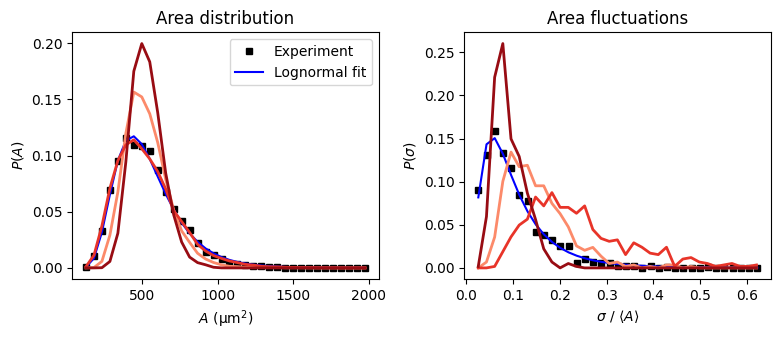

In [24]:
# create figure
plt.figure(figsize=(8,3.5))
plt.subplot(121)
plt.title("Area distribution")
plt.xlabel(r"$A$ (µm$^2$)")
plt.ylabel(r"$P(A)$")

plt.plot(A,     freq_A,     'ks', ms=4, label="Experiment")
plt.plot(A,     A_lognorm,  'b-',       label="Lognormal fit")
for A_tmp, freq_tmp, c in zip(A_sim, freq_A_sim, colors):
    plt.plot(A_tmp, freq_tmp, '-', c=c, lw=2)
plt.legend()

# create subfigure
plt.subplot(122)
plt.title("Area fluctuations")
plt.xlabel(r"$\sigma~/~\langle A \rangle$")
plt.ylabel(r"$P(\sigma)$")

plt.plot(std[1:],     freq_std[1:],     'ks', ms=4)
plt.plot(std[1:],     std_lognorm[1:],  'b-')
for std_tmp, freq_tmp, c in zip(std_sim, freq_std_sim, colors):
    plt.plot(std_tmp[1:], freq_tmp[1:], '-', c=c, lw=2)

# save
plt.tight_layout()
# plt.savefig("results/tmp/area_distribution_and_fluctuation.png", dpi=300)

## Aspect ratio distributions

In [25]:
# Extract experimental distributions
tmp_dist, tmp_std = extract_param_from_datasets(cellprops, masks, param="planar")

# get histogram curves
pmin = 0.9
pmax = 3
pxy, freq_pxy, _ = hist_to_curve(tmp_dist, 36, hist_range=[pmin, pmax])
std, freq_std, _ = hist_to_curve(tmp_std,  36, hist_range=[0, pmax/4])

# Normalise
freq_pxy = freq_pxy / np.ma.sum(freq_pxy)
freq_std = freq_std / np.ma.sum(freq_std[1:])

# Express std as relative of mean
std = std / np.ma.mean(tmp_dist)

In [26]:
# Extract simulation distributions
tmp_dists, tmp_stds = extract_param_from_simulation(list_vms, param="planar")

# get histogram curves
pxy_sim      = []
std_sim      = []
freq_pxy_sim = []
freq_std_sim = []
for tmp_dist, tmp_std in zip(tmp_dists, tmp_stds):
    pxy_tmp, freq_pxy_tmp, _ = hist_to_curve(tmp_dist, 36, hist_range=[pmin, pmax])
    std_tmp, freq_std_tmp, _ = hist_to_curve(tmp_std,  36, hist_range=[0, pmax/4])

    # Normalise
    freq_pxy_tmp = freq_pxy_tmp / np.ma.sum(freq_pxy_tmp)
    freq_std_tmp = freq_std_tmp / np.ma.sum(freq_std_tmp[1:])

    # Express std as relative of mean
    std_tmp = std_tmp / np.ma.mean(tmp_dist)

    pxy_sim.append(pxy_tmp)
    std_sim.append(std_tmp)
    freq_pxy_sim.append(freq_pxy_tmp)
    freq_std_sim.append(freq_std_tmp)

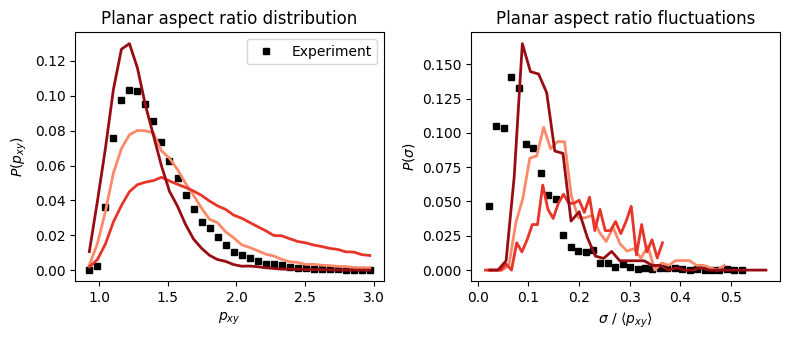

In [27]:
# create figure
plt.figure(figsize=(8,3.5))
plt.subplot(121)
plt.title("Planar aspect ratio distribution")
plt.xlabel(r"$p_{xy}$")
plt.ylabel(r"$P(p_{xy})$")

plt.plot(pxy,     freq_pxy,     'ks', ms=4, label="Experiment")
for pxy_tmp, freq_tmp, c in zip(pxy_sim, freq_pxy_sim, colors):
    plt.plot(pxy_tmp, freq_tmp, '-', c=c, lw=2)
plt.legend()

# create subfigure
plt.subplot(122)
plt.title("Planar aspect ratio fluctuations")
plt.xlabel(r"$\sigma~/~\langle p_{xy} \rangle$")
plt.ylabel(r"$P(\sigma)$")

plt.plot(std[1:],     freq_std[1:],     'ks', ms=4)
for std_tmp, freq_tmp, c in zip(std_sim, freq_std_sim, colors):
    plt.plot(std_tmp[1:], freq_tmp[1:], '-', c=c, lw=2)


# save
plt.tight_layout()
# plt.savefig("results/tmp/planar_aspect_ratio_distribution_and_fluctuation.png", dpi=300)

In [28]:
# Extract experimental distributions
tmp_dist, tmp_std = extract_param_from_datasets(cellprops, masks, param="vertical")

# get histogram curves
pmin = 0
pmax = 0.6
ph,  freq_ph,  _ = hist_to_curve(tmp_dist, 36, hist_range=[pmin, pmax])
std, freq_std, _ = hist_to_curve(tmp_std,  36, hist_range=[0, pmax/4])

# Normalise
freq_ph = freq_ph / np.ma.sum(freq_ph)
freq_std = freq_std / np.ma.sum(freq_std[1:])

# Express std as relative of mean
std = std / np.ma.mean(tmp_dist)

In [29]:
# Extract simulation distributions
tmp_dists, tmp_stds = extract_param_from_simulation(list_vms, param="vertical")

# get histogram curves
ph_sim      = []
std_sim      = []
freq_ph_sim = []
freq_std_sim = []
for tmp_dist, tmp_std in zip(tmp_dists, tmp_stds):
    ph_tmp,  freq_ph_tmp, _  = hist_to_curve(tmp_dist, 36, hist_range=[pmin, pmax])
    std_tmp, freq_std_tmp, _ = hist_to_curve(tmp_std,  36, hist_range=[0, pmax/4])

    # Normalise
    freq_ph_tmp  = freq_ph_tmp / np.ma.sum(freq_ph_tmp)
    freq_std_tmp = freq_std_tmp / np.ma.sum(freq_std_tmp[1:])

    # Express std as relative of mean
    std_tmp = std_tmp / np.ma.mean(tmp_dist)

    ph_sim.append(ph_tmp)
    std_sim.append(std_tmp)
    freq_ph_sim.append(freq_ph_tmp)
    freq_std_sim.append(freq_std_tmp)

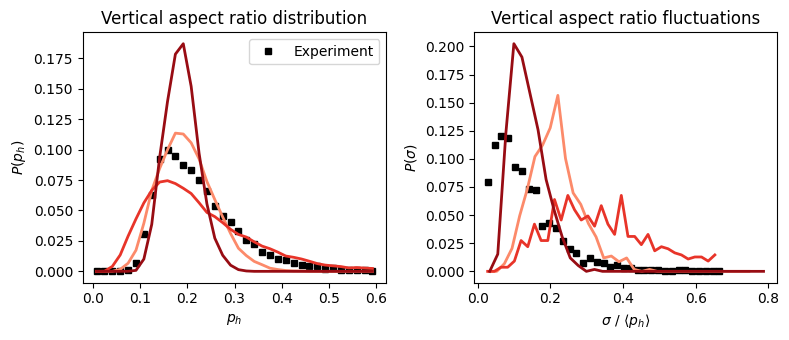

In [30]:
# create figure
plt.figure(figsize=(8,3.5))
plt.subplot(121)
plt.title("Vertical aspect ratio distribution")
plt.xlabel(r"$p_{h}$")
plt.ylabel(r"$P(p_{h})$")

plt.plot(ph,     freq_ph,     'ks', ms=4, label="Experiment")
for ph_tmp, freq_tmp, c in zip(ph_sim, freq_ph_sim, colors):
    plt.plot(ph_tmp, freq_tmp, '-', c=c, lw=2)
plt.legend()


# create subfigure
plt.subplot(122)
plt.title("Vertical aspect ratio fluctuations")
plt.xlabel(r"$\sigma~/~\langle p_{h} \rangle$")
plt.ylabel(r"$P(\sigma)$")

plt.plot(std[1:],     freq_std[1:],     'ks', ms=4)
for std_tmp, freq_tmp, c in zip(std_sim, freq_std_sim, colors):
    plt.plot(std_tmp[1:], freq_tmp[1:], '-', c=c, lw=2)

# save
plt.tight_layout()
# plt.savefig("results/tmp/vertical_aspect_ratio_distribution_and_fluctuation.png", dpi=300)


## Cell speed distribution

In [31]:
# Extract experimental distributions
tmp_dist, tmp_std = extract_param_from_datasets(cellprops, masks, param="speed")

# get histogram curves
v, freq_v, _ = hist_to_curve(tmp_dist, 30, hist_range=[0, 60])

# Normalise
freq_v = freq_v / np.ma.sum(freq_v)

In [32]:
# Fit lognormal to distributions to experimental data
v_params, v_popt = curve_fit(gamma_distribution, v, freq_v, p0=[2, np.mean(tmp_dist)])
v_gamma          = gamma_distribution(v, *v_params)

print("Area distribution")
print(f"Shape parameter: {v_params[0]:0.2f} +/- {v_popt[0,0]:0.2f}")
print(f"Scale parameter: {v_params[1]:0.2f} +/- {v_popt[1,1]:0.2f}")

Area distribution
Shape parameter: 3.27 +/- 0.01
Scale parameter: 5.51 +/- 0.02


In [33]:
# Extract experimental distributions
tmp_dists, tmp_stds = extract_param_from_simulation(list_vms, param="speed")

# get histogram curves
v_sim      = []
freq_v_sim = []

for tmp_dist in tmp_dists:
    v_tmp, freq_tmp, _ = hist_to_curve(tmp_dist, 30, hist_range=[0, 60])

    # Normalise
    freq_tmp = freq_tmp / np.ma.sum(freq_tmp)

    v_sim.append(v_tmp)
    freq_v_sim.append(freq_tmp)

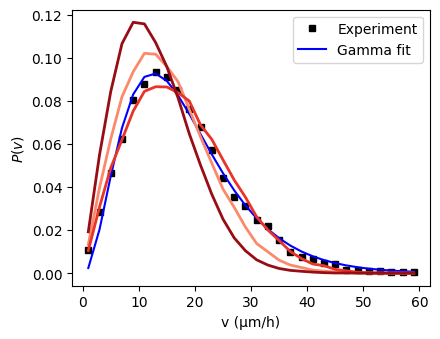

In [34]:
# create figure
plt.figure(figsize=(4.5,3.5))
plt.xlabel(r"v (µm/h)")
plt.ylabel(r"$P(v)$")

plt.plot(v,     freq_v,     'ks', ms=4, label="Experiment")
plt.plot(v,     v_gamma,    'b-',       label="Gamma fit")
for v_tmp, freq_tmp, c in zip(v_sim, freq_v_sim, colors):
    plt.plot(v_tmp, freq_tmp, '-', c=c, lw=2)
plt.legend()

plt.tight_layout()
# plt.savefig("results/tmp/speed_distribution.png", dpi=300)